In [1]:
import sys
import torch
sys.path.insert(0, '..')
sys.path.insert(0, '../bart/python')  # BART Python wrapper (bart.py + cfl.py)
from train_utils import FastMRIMaskGenerator, simulate_undersampling, psnr
from DcTNN.dc import fft_2d, ifft_2d, FFT_DC, KSpace_DC

try:
    from bart import bart as bart_call
    import cfl as cfl_mod
    BART_PYTHON = True
except ImportError:
    BART_PYTHON = False


kspace : (36, 640, 372) complex64
rss    : (36, 320, 320) float32


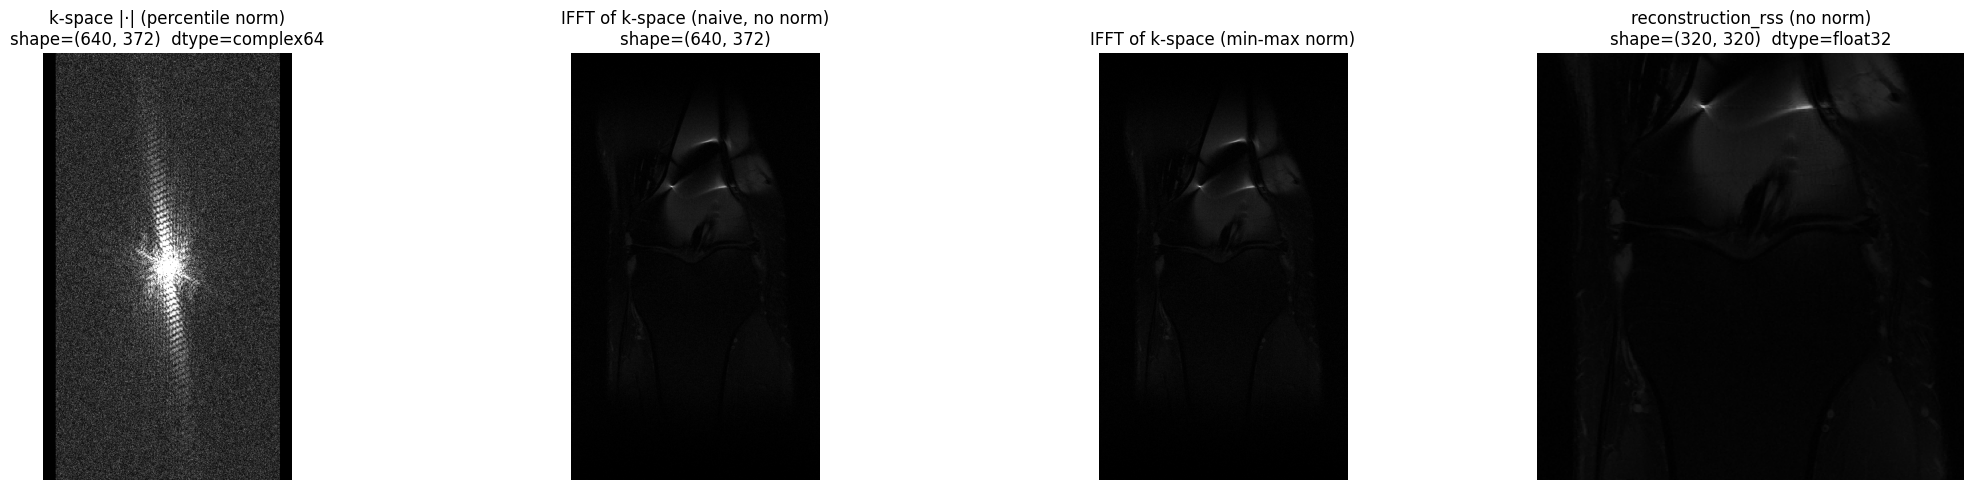

In [51]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

FILE = "../data/knee dataset/file1000001.h5"

with h5py.File(FILE, "r") as f:
    kspace = f["kspace"][:]               # (36, 640, 372) complex64
    rss    = f["reconstruction_rss"][:]   # (36, 320, 320) float32

print("kspace :", kspace.shape, kspace.dtype)
print("rss    :", rss.shape, rss.dtype)

sl  = kspace.shape[0] // 2
ks  = kspace[sl]          # (640, 372) complex64
rss_sl = rss[sl]          # (320, 320) float32

naive = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(ks))))

def norm(x, lo=1, hi=99):
    """Clip to percentile range then scale to [0, 1]."""
    a, b = np.percentile(x, lo), np.percentile(x, hi)
    return np.clip((x - a) / (b - a + 1e-8), 0, 1)

def minmax_norm(x):
    """Plain min-max scale to [0, 1], no clipping."""
    a, b = x.min(), x.max()
    return (x - a) / (b - a + 1e-8)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(norm(np.abs(ks)), cmap="gray")
axes[0].set_title(f"k-space |·| (percentile norm)\nshape={ks.shape}  dtype={ks.dtype}")
axes[0].axis("off")

axes[1].imshow(naive, cmap="gray")
axes[1].set_title(f"IFFT of k-space (naive, no norm)\nshape={naive.shape}")
axes[1].axis("off")

axes[2].imshow(minmax_norm(naive), cmap="gray")
axes[2].set_title("IFFT of k-space (min-max norm)")
axes[2].axis("off")

axes[3].imshow(rss_sl, cmap="gray")
axes[3].set_title(f"reconstruction_rss (no norm)\nshape={rss_sl.shape}  dtype={rss_sl.dtype}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [52]:
torch.device("cpu")

device(type='cpu')

## Normalized TV Baseline (Single-Coil, No BART)

This section isolates the custom TV solver before comparing against BART.

Changes relative to the previous version:
- reconstruct only with the in-notebook TV solver
- normalize full k-space to unit peak magnitude before masking and TV updates
- print k-space and image scales explicitly so `lambda` is interpretable
- add finite-value / divergence guards inside the iterative loop
- sweep `lambda` on a log scale to separate over-regularization from instability
- allow plain ISTA (`use_momentum=False`) or FISTA-style momentum (`use_momentum=True`)

The goal here is to determine whether the failure mode is:
- data-scale / `lambda` mismatch
- step-size / momentum instability
- or a deeper modeling bug



In [53]:
from fastmri.data.subsample import RandomMaskFunc
from skimage.restoration import denoise_tv_chambolle

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MASK_SEED = 1234
TV_ITERS = 200
TV_STEP_SIZE = 0.1
TV_USE_MOMENTUM = False
TV_LAM_SWEEP = [1e-5, 1e-4, 1e-3, 1e-2]
CENTER_FRACTIONS = {4: 0.08, 6: 0.04, 8: 0.04}
CROP_SHAPE = (320, 320)

print('device:', DEVICE)


def fft2c_np(img):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img, axes=(-2, -1)), norm='ortho'), axes=(-2, -1))


def ifft2c_np(ks):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ks, axes=(-2, -1)), norm='ortho'), axes=(-2, -1))


def center_crop_np(arr, out_shape=CROP_SHAPE):
    h, w = arr.shape
    out_h, out_w = out_shape
    h0 = (h - out_h) // 2
    w0 = (w - out_w) // 2
    return arr[h0:h0 + out_h, w0:w0 + out_w]


def fastmri_random_mask_first_principles(shape, accel, seed=MASK_SEED, center_fraction=None):
    h, w = shape
    if center_fraction is None:
        center_fraction = CENTER_FRACTIONS.get(accel, 0.04 if accel >= 6 else 0.08)
    num_low = max(1, min(int(round(w * center_fraction)), w))
    prob = (w / accel - num_low) / max(w - num_low, 1)
    prob = float(np.clip(prob, 0.0, 1.0))

    rng = np.random.RandomState(seed)
    accel_mask = (rng.uniform(size=w) < prob).astype(np.float32)
    center_mask = np.zeros(w, dtype=np.float32)
    pad = (w - num_low + 1) // 2
    center_mask[pad:pad + num_low] = 1.0

    mask_1d = np.maximum(center_mask, accel_mask)
    mask_2d = np.repeat(mask_1d[None, :], h, axis=0).astype(np.float32)
    return mask_2d, num_low


def fastmri_random_mask_repo(shape, accel, seed=MASK_SEED):
    h, w = shape
    mask_func = RandomMaskFunc(
        center_fractions=[CENTER_FRACTIONS.get(accel, 0.04 if accel >= 6 else 0.08)],
        accelerations=[accel],
        seed=seed,
    )
    mask, num_low = mask_func((1, h, w, 1), seed=seed)
    mask_1d = mask.squeeze().numpy().astype(np.float32)
    mask_2d = np.repeat(mask_1d[None, :], h, axis=0)
    return mask_2d, int(num_low)


def verify_fastmri_mask(shape, accel, seed=MASK_SEED):
    fp_mask, fp_low = fastmri_random_mask_first_principles(shape, accel, seed=seed)
    repo_mask, repo_low = fastmri_random_mask_repo(shape, accel, seed=seed)
    diff = np.abs(fp_mask - repo_mask)
    print('mask verification')
    print('  shape                :', shape)
    print('  first-principles mean:', fp_mask.mean())
    print('  repo helper mean     :', repo_mask.mean())
    print('  first-principles low :', fp_low)
    print('  repo helper low      :', repo_low)
    print('  differing entries    :', int(diff.sum()))
    return fp_mask, repo_mask


def psnr_np(gt, pred):
    mse = np.mean((gt - pred) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(gt.max() / (np.sqrt(mse) + 1e-12))


def ssim_simple(gt, pred):
    mu_g, mu_p = gt.mean(), pred.mean()
    c1 = (0.01 * gt.max()) ** 2
    c2 = (0.03 * gt.max()) ** 2
    sig_g = np.var(gt)
    sig_p = np.var(pred)
    sig_gp = np.mean((gt - mu_g) * (pred - mu_p))
    return ((2 * mu_g * mu_p + c1) * (2 * sig_gp + c2)) / ((mu_g**2 + mu_p**2 + c1) * (sig_g + sig_p + c2))


def tv_recon_singlecoil(us_ks_centered, mask_2d, lam, num_iters=TV_ITERS, step_size=TV_STEP_SIZE, use_momentum=TV_USE_MOMENTUM):
    y = us_ks_centered.astype(np.complex64)
    mask = mask_2d.astype(np.float32)
    x = ifft2c_np(y)
    z = x.copy()
    t = 1.0

    history = []
    diverged = False
    diverged_iter = None

    for i in range(num_iters):
        grad = ifft2c_np(mask * (fft2c_np(z) - y))
        z_step = z - step_size * grad

        if not np.all(np.isfinite(z_step)):
            diverged = True
            diverged_iter = i
            print(f'Diverged before TV prox at iteration {i}')
            break

        x_r = denoise_tv_chambolle(
            z_step.real.astype(np.float32),
            weight=lam * step_size,
            channel_axis=None,
        )
        x_i = denoise_tv_chambolle(
            z_step.imag.astype(np.float32),
            weight=lam * step_size,
            channel_axis=None,
        )
        x_next = x_r.astype(np.complex64) + 1j * x_i.astype(np.complex64)

        if not np.all(np.isfinite(x_next)):
            diverged = True
            diverged_iter = i
            print(f'Diverged after TV prox at iteration {i}')
            break

        if use_momentum:
            t_next = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
            z = x_next + ((t - 1.0) / t_next) * (x_next - x)
            t = t_next
        else:
            z = x_next

        x = x_next

        if i in {0, 1, 2, 4, 9, 24, 49, 99, num_iters - 1}:
            history.append({
                'iter': i,
                'max_abs': float(np.abs(x).max()),
                'mean_abs': float(np.abs(x).mean()),
            })

    return x, {
        'diverged': diverged,
        'diverged_iter': diverged_iter,
        'history': history,
        'step_size': step_size,
        'use_momentum': use_momentum,
        'lambda': lam,
    }


def run_tv_lambda_sweep(full_ks, accel, lam_values=TV_LAM_SWEEP, seed=MASK_SEED, num_iters=TV_ITERS, step_size=TV_STEP_SIZE, use_momentum=TV_USE_MOMENTUM):
    ks_scale = max(float(np.abs(full_ks).max()), 1e-12)
    full_ks_norm = (full_ks / ks_scale).astype(np.complex64)
    gt_full = np.abs(ifft2c_np(full_ks_norm)).astype(np.float32)
    gt_crop = center_crop_np(gt_full, CROP_SHAPE)

    print(f'R={accel} data scale diagnostics')
    print('  raw |k-space| max :', float(np.abs(full_ks).max()))
    print('  raw |k-space| mean:', float(np.abs(full_ks).mean()))
    print('  k-space scale used :', ks_scale)
    print('  norm GT max        :', float(gt_crop.max()))
    print('  norm GT mean       :', float(gt_crop.mean()))

    mask_r, _ = verify_fastmri_mask(full_ks.shape, accel, seed=seed)
    us_ks_norm = full_ks_norm * mask_r
    zf_norm = np.abs(ifft2c_np(us_ks_norm)).astype(np.float32)
    zf_crop = center_crop_np(zf_norm, CROP_SHAPE)

    results = []
    for lam in lam_values:
        recon_complex, info = tv_recon_singlecoil(
            us_ks_norm,
            mask_r,
            lam=lam,
            num_iters=num_iters,
            step_size=step_size,
            use_momentum=use_momentum,
        )
        recon_mag = np.abs(recon_complex).astype(np.float32)
        recon_crop = center_crop_np(recon_mag, CROP_SHAPE)
        results.append({
            'lambda': lam,
            'recon_crop': recon_crop,
            'psnr': psnr_np(gt_crop, recon_crop),
            'ssim': ssim_simple(gt_crop, recon_crop),
            'info': info,
        })

    return {
        'ks_scale': ks_scale,
        'gt_crop': gt_crop,
        'zf_crop': zf_crop,
        'zf_psnr': psnr_np(gt_crop, zf_crop),
        'zf_ssim': ssim_simple(gt_crop, zf_crop),
        'results': results,
    }



device: cpu


R=4 data scale diagnostics
  raw |k-space| max : 0.007223865017294884
  raw |k-space| mean: 1.086293559637852e-05
  k-space scale used : 0.007223865017294884
  norm GT max        : 0.11559107899665833
  norm GT mean       : 0.00407425407320261
mask verification
  shape                : (640, 372)
  first-principles mean: 0.25268817
  repo helper mean     : 0.25268817
  first-principles low : 30
  repo helper low      : 30
  differing entries    : 0
R=4 | zero-filled PSNR=39.09 dB | SSIM=0.9563
  lambda=1.0e-05 | PSNR=39.09 dB | SSIM=0.9563 | diverged=False | iter=None | momentum=False | step=0.1
    iter=  0 | max|x|=6.7097e-02 | mean|x|=2.5394e-03
    iter=  1 | max|x|=6.7095e-02 | mean|x|=2.5384e-03
    iter=  2 | max|x|=6.7094e-02 | mean|x|=2.5375e-03
    iter=  4 | max|x|=6.7096e-02 | mean|x|=2.5361e-03
    iter=  9 | max|x|=6.7116e-02 | mean|x|=2.5334e-03
    iter= 24 | max|x|=6.7239e-02 | mean|x|=2.5302e-03
    iter= 49 | max|x|=6.7500e-02 | mean|x|=2.5289e-03
    iter= 99 | max|

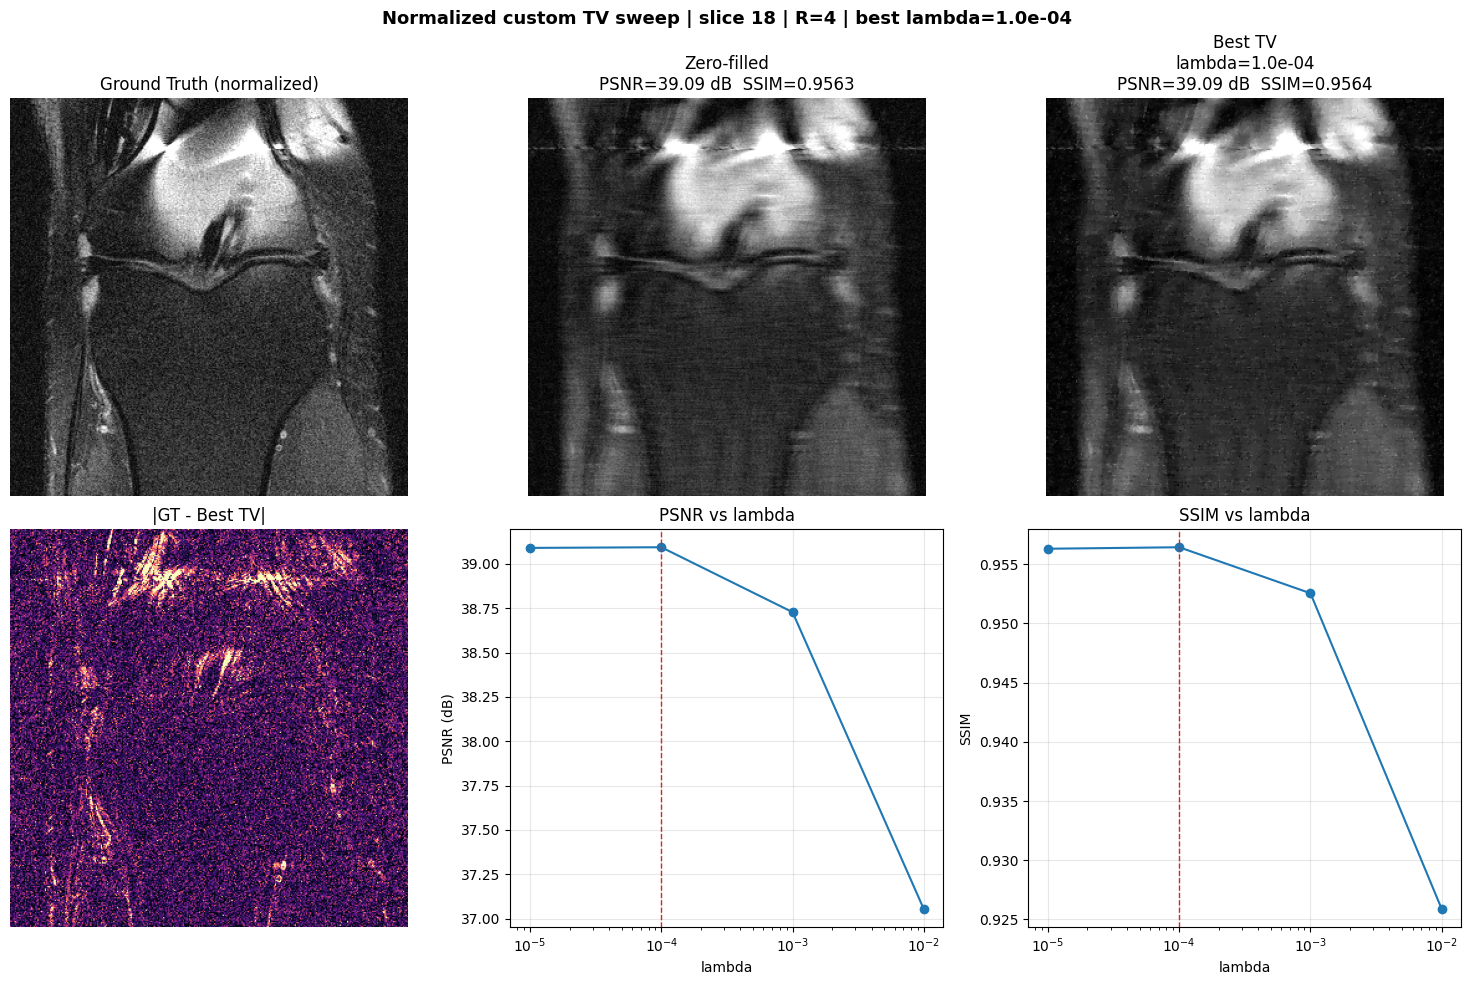

R=8 data scale diagnostics
  raw |k-space| max : 0.007223865017294884
  raw |k-space| mean: 1.086293559637852e-05
  k-space scale used : 0.007223865017294884
  norm GT max        : 0.11559107899665833
  norm GT mean       : 0.00407425407320261
mask verification
  shape                : (640, 372)
  first-principles mean: 0.13440861
  repo helper mean     : 0.13440861
  first-principles low : 15
  repo helper low      : 15
  differing entries    : 0
R=8 | zero-filled PSNR=36.38 dB | SSIM=0.9160
  lambda=1.0e-05 | PSNR=36.38 dB | SSIM=0.9160 | diverged=False | iter=None | momentum=False | step=0.1
    iter=  0 | max|x|=4.5253e-02 | mean|x|=2.4633e-03
    iter=  1 | max|x|=4.5250e-02 | mean|x|=2.4625e-03
    iter=  2 | max|x|=4.5248e-02 | mean|x|=2.4617e-03
    iter=  4 | max|x|=4.5245e-02 | mean|x|=2.4604e-03
    iter=  9 | max|x|=4.5241e-02 | mean|x|=2.4582e-03
    iter= 24 | max|x|=4.5248e-02 | mean|x|=2.4555e-03
    iter= 49 | max|x|=4.5278e-02 | mean|x|=2.4546e-03
    iter= 99 | max|

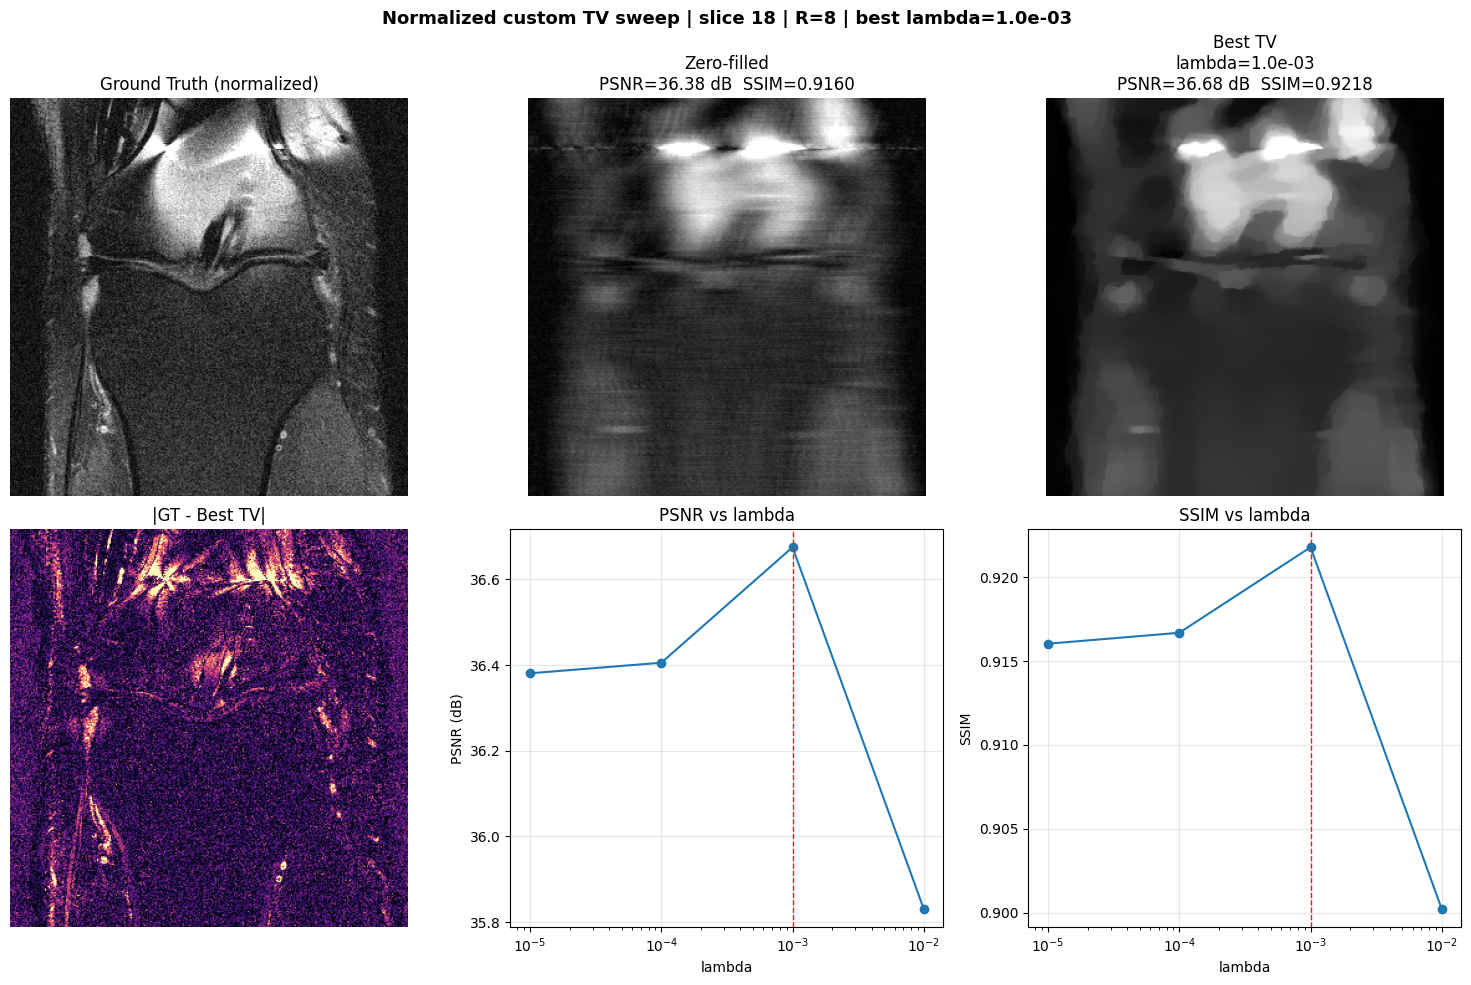

In [54]:
FULL_KS = ks

for ACCEL_R in [4, 8]:
    sweep = run_tv_lambda_sweep(
        FULL_KS,
        accel=ACCEL_R,
        lam_values=TV_LAM_SWEEP,
        num_iters=TV_ITERS,
        step_size=TV_STEP_SIZE,
        use_momentum=TV_USE_MOMENTUM,
    )

    gt_crop = sweep['gt_crop']
    zf_crop = sweep['zf_crop']
    zf_psnr = sweep['zf_psnr']
    zf_ssim = sweep['zf_ssim']

    print(f'R={ACCEL_R} | zero-filled PSNR={zf_psnr:.2f} dB | SSIM={zf_ssim:.4f}')
    for item in sweep['results']:
        info = item['info']
        print(
            f"  lambda={item['lambda']:.1e} | PSNR={item['psnr']:.2f} dB | SSIM={item['ssim']:.4f} | "
            f"diverged={info['diverged']} | iter={info['diverged_iter']} | momentum={info['use_momentum']} | step={info['step_size']}"
        )
        for snap in info['history']:
            print(
                f"    iter={snap['iter']:3d} | max|x|={snap['max_abs']:.4e} | mean|x|={snap['mean_abs']:.4e}"
            )

    best = max(sweep['results'], key=lambda item: item['psnr'])
    best_lam = best['lambda']
    best_crop = best['recon_crop']
    err_max = np.percentile(np.abs(gt_crop - best_crop), 99)
    gt_vmax = np.percentile(gt_crop, 99)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(
        f'Normalized custom TV sweep | slice {sl} | R={ACCEL_R} | best lambda={best_lam:.1e}',
        fontsize=13,
        fontweight='bold',
    )

    axes[0, 0].imshow(gt_crop, cmap='gray', vmin=0, vmax=gt_vmax)
    axes[0, 0].set_title('Ground Truth (normalized)')
    axes[0, 1].imshow(zf_crop, cmap='gray', vmin=0, vmax=gt_vmax)
    axes[0, 1].set_title(f'Zero-filled\nPSNR={zf_psnr:.2f} dB  SSIM={zf_ssim:.4f}')
    axes[0, 2].imshow(best_crop, cmap='gray', vmin=0, vmax=gt_vmax)
    axes[0, 2].set_title(f'Best TV\nlambda={best_lam:.1e}\nPSNR={best["psnr"]:.2f} dB  SSIM={best["ssim"]:.4f}')

    axes[1, 0].imshow(np.abs(gt_crop - best_crop), cmap='magma', vmin=0, vmax=err_max)
    axes[1, 0].set_title('|GT - Best TV|')

    lam_axis = [item['lambda'] for item in sweep['results']]
    psnr_axis = [item['psnr'] for item in sweep['results']]
    ssim_axis = [item['ssim'] for item in sweep['results']]
    axes[1, 1].semilogx(lam_axis, psnr_axis, marker='o')
    axes[1, 1].axvline(best_lam, color='tab:red', linestyle='--', linewidth=1)
    axes[1, 1].set_title('PSNR vs lambda')
    axes[1, 1].set_xlabel('lambda')
    axes[1, 1].set_ylabel('PSNR (dB)')
    axes[1, 1].grid(True, alpha=0.3)

    axes[1, 2].semilogx(lam_axis, ssim_axis, marker='o')
    axes[1, 2].axvline(best_lam, color='tab:red', linestyle='--', linewidth=1)
    axes[1, 2].set_title('SSIM vs lambda')
    axes[1, 2].set_xlabel('lambda')
    axes[1, 2].set_ylabel('SSIM')
    axes[1, 2].grid(True, alpha=0.3)

    for ax in axes.ravel():
        if hasattr(ax, 'images') and ax.images:
            ax.axis('off')
    plt.tight_layout()
    plt.show()



In [1]:
import os
import sys
import json
from glob import glob

import numpy as np
import torch
import matplotlib.pyplot as plt
WORKING_DIR = '/Users/amlannag/Desktop/MambaCS'
sys.path.insert(0, WORKING_DIR)
sys.path.insert(0, os.path.join(WORKING_DIR, 'notebooks'))

from notebook_inference import (
    psnr, ssim,
    load_test_images, png_to_kspace, to_magnitude, img_to_log_kspace,
    run_inference_png, plot_inference_png,
)
from inference import load_experiment_model
from DcTNN.dc import fft_2d, ifft_2d

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [5]:
TEST_DATA_DIR = '../data/oasis_test'
test_images = load_test_images(TEST_DATA_DIR)

Loaded 20 PNG slices from '../data/oasis_test'


In [44]:
k_space = fft_2d(torch.tensor(test_images[0][1]).unsqueeze(0).unsqueeze(0))
img_us = ifft_2d(k_space)

mean_r = img_us.real.mean(dim=(-2, -1), keepdim=True)
std_r  = img_us.real.std( dim=(-2, -1), keepdim=True).clamp(min=1e-8)
mean_i = img_us.imag.mean(dim=(-2, -1), keepdim=True)
std_i  = img_us.imag.std( dim=(-2, -1), keepdim=True).clamp(min=1e-8)

img_us_norm = torch.complex((img_us.real - mean_r) / std_r,
                            (img_us.imag - mean_i) / std_i)


(array([3.7108e+04, 2.8100e+02, 2.2500e+02, 9.4000e+02, 7.3800e+02,
        1.0520e+03, 6.9500e+02, 9.3800e+02, 5.6400e+02, 7.7300e+02,
        7.2600e+02, 4.6000e+02, 7.3300e+02, 4.2200e+02, 6.9900e+02,
        3.9200e+02, 6.3700e+02, 4.5400e+02, 7.0900e+02, 5.0700e+02,
        7.4900e+02, 8.5300e+02, 6.3200e+02, 9.4700e+02, 6.1500e+02,
        9.8200e+02, 5.2900e+02, 8.2700e+02, 5.0500e+02, 6.9000e+02,
        7.1800e+02, 5.0500e+02, 7.6400e+02, 4.7800e+02, 8.1400e+02,
        5.5100e+02, 9.0600e+02, 6.4700e+02, 9.2700e+02, 4.1800e+02,
        3.5800e+02, 1.2800e+02, 6.1000e+01, 6.8000e+01, 3.8000e+01,
        6.8000e+01, 5.2000e+01, 6.6000e+01, 5.0000e+01, 6.1000e+01,
        6.1000e+01, 3.5000e+01, 6.8000e+01, 4.8000e+01, 6.4000e+01,
        4.7000e+01, 5.9000e+01, 4.1000e+01, 6.4000e+01, 3.3000e+01,
        7.3000e+01, 5.2000e+01, 3.1000e+01, 7.2000e+01, 3.5000e+01,
        4.7000e+01, 3.6000e+01, 5.2000e+01, 4.2000e+01, 6.7000e+01,
        6.9000e+01, 4.3000e+01, 3.9000e+01, 4.00

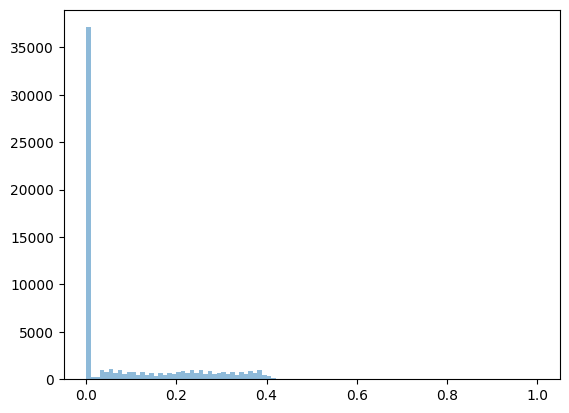

In [52]:
plt.hist(img_us.real.flatten().numpy(), bins=100, alpha=0.5, label='Real part')

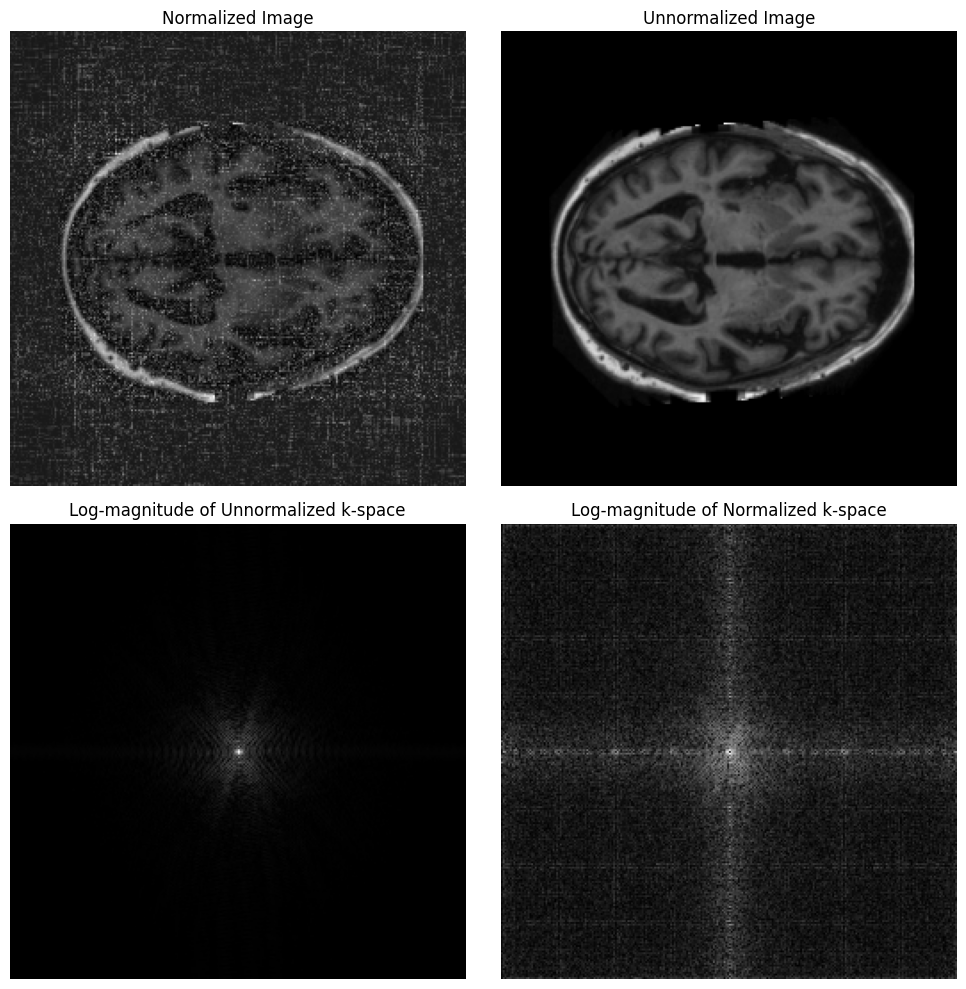

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(np.abs(img_us_norm[0, 0].numpy()), cmap='gray')
axes[0, 0].set_title('Normalized Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(img_us[0, 0].numpy()), cmap='gray')
axes[0, 1].set_title('Unnormalized Image')
axes[0, 1].axis('off')

axes[1, 0].imshow(np.log1p(np.abs(k_space[0, 0].numpy())), cmap='gray')
axes[1, 0].set_title('Log-magnitude of Unnormalized k-space')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.log1p(np.abs(kspace_norm[0, 0].numpy())), cmap='gray')
axes[1, 1].set_title('Log-magnitude of Normalized k-space')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

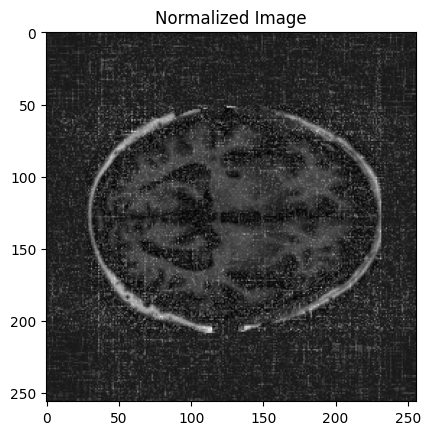

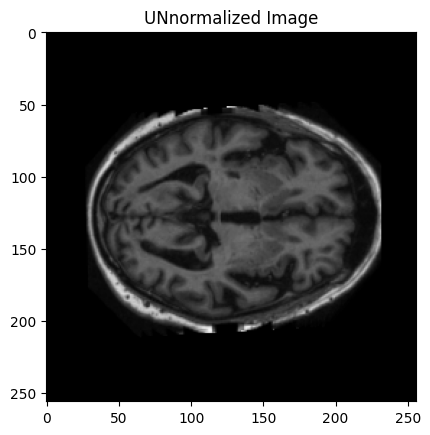

In [50]:
plt.imshow(np.abs(img_us_norm[0, 0].numpy()), cmap='gray')
plt.title('Normalized Image')
plt.show()

plt.imshow(np.abs(img_us[0, 0].numpy()), cmap='gray')
plt.title('UNnormalized Image')
plt.show()